In [1]:
import matplotlib.pyplot as plt
# import numpy as np

import config, plotting
from dimelo import parse_bam, plot_enrichment_profile

In [2]:
plt.style.use("plots.mpstyle")

In [3]:
reference_file = config.raw_data_dir / "chm13v2.0.fa"
top_tss_bed_file = config.processed_data_dir / "tss.gm12878_ranked.t2t_chm13v2.quartiles" / "q4.bed"
bam_dir = config.processed_data_dir
barcodes = [20, 22]

window_size = 1000
mod_prob_thresh = 0.75
smoothing = 25
n_cores = 10

cg_motifs = [f"{b}CG,1" for b in ("G", "A", "T", "C", "W")]
gc_motifs = [f"GC{b},1" for b in ("G", "A", "T", "C", "H")]
condition_labels = ["control", "gc_access"]
motif_lists = [cg_motifs, gc_motifs]
motif_labels = ["CG", "GC"]
motif_colors = [plotting.default_palette_map["WCG,1"], plotting.default_palette_map["GCH,1"]]

y_lim = (-0.01, 0.5)

In [ ]:
for barcode, condition_label in zip(barcodes, condition_labels):
    bam_file = bam_dir / f"barcode{barcode:02}.sorted.bam"
    for motif_list, motif_label in zip(motif_lists, motif_labels):
        output_id = f"{condition_label}.{motif_label}"
        parse_bam.pileup(
            input_file=bam_file,
            output_name=f"pileup.{output_id}",
            ref_genome=reference_file,
            output_directory=config.processed_data_dir,
            regions=top_tss_bed_file,
            motifs=motif_list,
            thresh=mod_prob_thresh,
            window_size=window_size,
            cores=n_cores,
            override_checks=True
        )

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

...

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

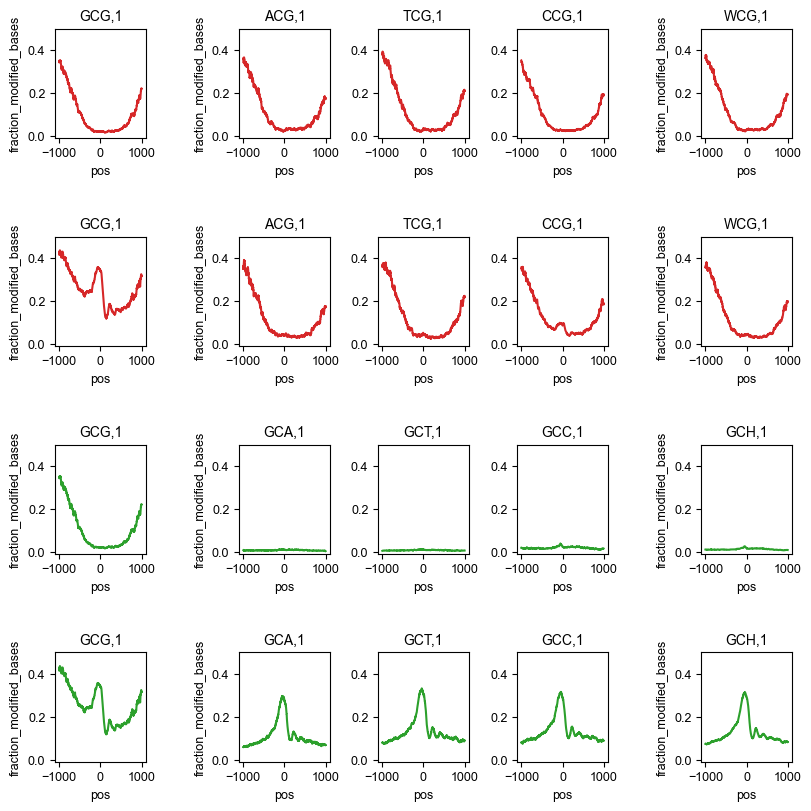

In [4]:
fig = plt.figure(layout="constrained", figsize=(8, 8))
n_rows = len(motif_labels) + len(condition_labels)
n_cols = len(cg_motifs)
n_inner_cols = n_cols - 2
width_padding = 0.3
height_padding = 0.2
outer_spec = fig.add_gridspec(n_rows, n_cols + 2, width_ratios=[1, width_padding] + [1]*n_inner_cols + [width_padding, 1], hspace=height_padding)

row_idx = 0
for motif_idx, (motif_list, motif_label, color) in enumerate(zip(motif_lists, motif_labels, motif_colors)):
    for condition_idx, condition_label in enumerate(condition_labels):
        for col_idx, motif in enumerate(motif_list):
            output_id = f"{condition_label}.{motif_label}"
            if col_idx == 0:
                spec_col_idx = col_idx
            elif col_idx == n_cols - 1:
                spec_col_idx = col_idx + 2
            else:
                spec_col_idx = col_idx + 1
            ax = fig.add_subplot(outer_spec[row_idx, spec_col_idx])
            plot_enrichment_profile.plot_enrichment_profile(
                mod_file_names=[config.processed_data_dir / f"pileup.{output_id}" / "pileup.sorted.bed.gz"],
                regions_list=[top_tss_bed_file],
                motifs=[motif],
                sample_names=[motif],
                window_size=window_size,
                regions_5to3prime=True,
                smooth_window=smoothing,
                ax=ax,
                palette={motif: color}
            )
            ax.set_title(motif)
            ax.set_ylim(y_lim)
            ax.legend().remove()
            ax.set_ylabel("fraction_modified_bases")
            if col_idx in (2, 3):
                ax.set_ylabel("")
        row_idx +=1

plt.savefig(config.figure_dir / f"motif_disambiguation_supplement.svg")
plt.show()
plt.close()